In [1]:
import pandas as pd

#read data file
df = pd.read_csv("./data/customer_shopping_data.csv")

df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [8]:
#review data structure
df.info()

#review data summary
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  str    
 1   customer_id     99457 non-null  str    
 2   gender          99457 non-null  str    
 3   age             99457 non-null  int64  
 4   category        99457 non-null  str    
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  str    
 8   invoice_date    99457 non-null  str    
 9   shopping_mall   99457 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 7.6 MB


,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [ ]:
#check null data
df.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
#data processing
df['Total_Revenue'] = df['quantity'] * df['price']
age_purchases = df.groupby('age')['quantity'].sum().reset_index()
category_revenue = df.groupby('category')['Total_Revenue'].sum().sort_values(ascending=False).reset_index()
mall_revenue = df.groupby('shopping_mall')['Total_Revenue'].sum().sort_values(ascending=False).reset_index()
payment_gender = pd.crosstab(df['payment_method'], df['gender'])

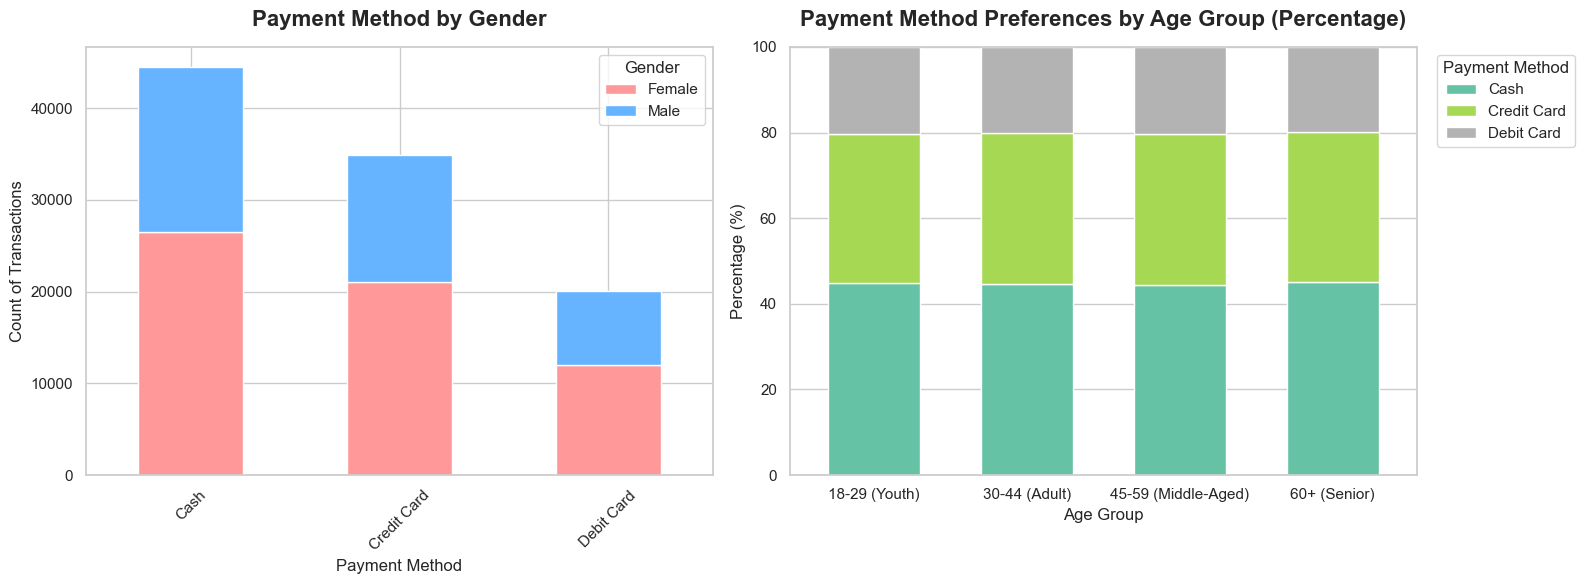

In [32]:
# Customer Analysis
f, ax = plt.subplots(1,2, figsize=(16, 6))
sns.set_theme(style="whitegrid")
# Payment Method by Gender
payment_gender.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=ax[0])
ax[0].set_title('Payment Method by Gender', fontsize=16, fontweight='bold', pad=15)
ax[0].set_xlabel('Payment Method')
ax[0].set_ylabel('Count of Transactions')
ax[0].tick_params(axis='x', rotation=45)
ax[0].legend(title='Gender')

# Payment methond by age
age_bins = [17, 29, 44, 59, 100]
age_labels = ['18-29 (Youth)', '30-44 (Adult)', '45-59 (Middle-Aged)', '60+ (Senior)']

df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# convert to percentage
payment_age = pd.crosstab(df['age_group'], df['payment_method'], normalize='index') * 100

# plot
payment_age.plot(kind='bar', stacked=True, cmap='Set2', width=0.6, ax=ax[1])
ax[1].set_title('Payment Method Preferences by Age Group (Percentage)', fontsize=16, fontweight='bold', pad=15)
ax[1].set_xlabel('Age Group', fontsize=12)
ax[1].set_ylabel('Percentage (%)', fontsize=12)

ax[1].tick_params(axis='x', rotation=0)

# 把 Legend (圖例) 移到圖表外面（右邊），避免擋到長條圖
ax[1].legend(title='Payment Method', bbox_to_anchor=(1.02, 1), loc='upper left')

# 加上百分比的限制（0-100%）
ax[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

Based on the visualizations, we can draw the following insights:
1. "Cash" is the most preferred payment method for both male and female customers, followed by "Credit Card" and "Debit Card." Furthermore, "Cash" consistently accounts for the highest percentage of payment preferences across all four age groups.
2. The dataset contains a higher volume of transactions from female customers compared to male customers.
3. There is no significant difference in payment method preferences across the different age groups, suggesting that payment behavior remains consistent regardless of age.

/var/folders/fs/d37yxrn944g4dkkv1_pdg0c00000gn/T/ipykernel_2956/304822710.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Revenue', y='shopping_mall', data=mall_revenue, palette='viridis', ax=ax[1])


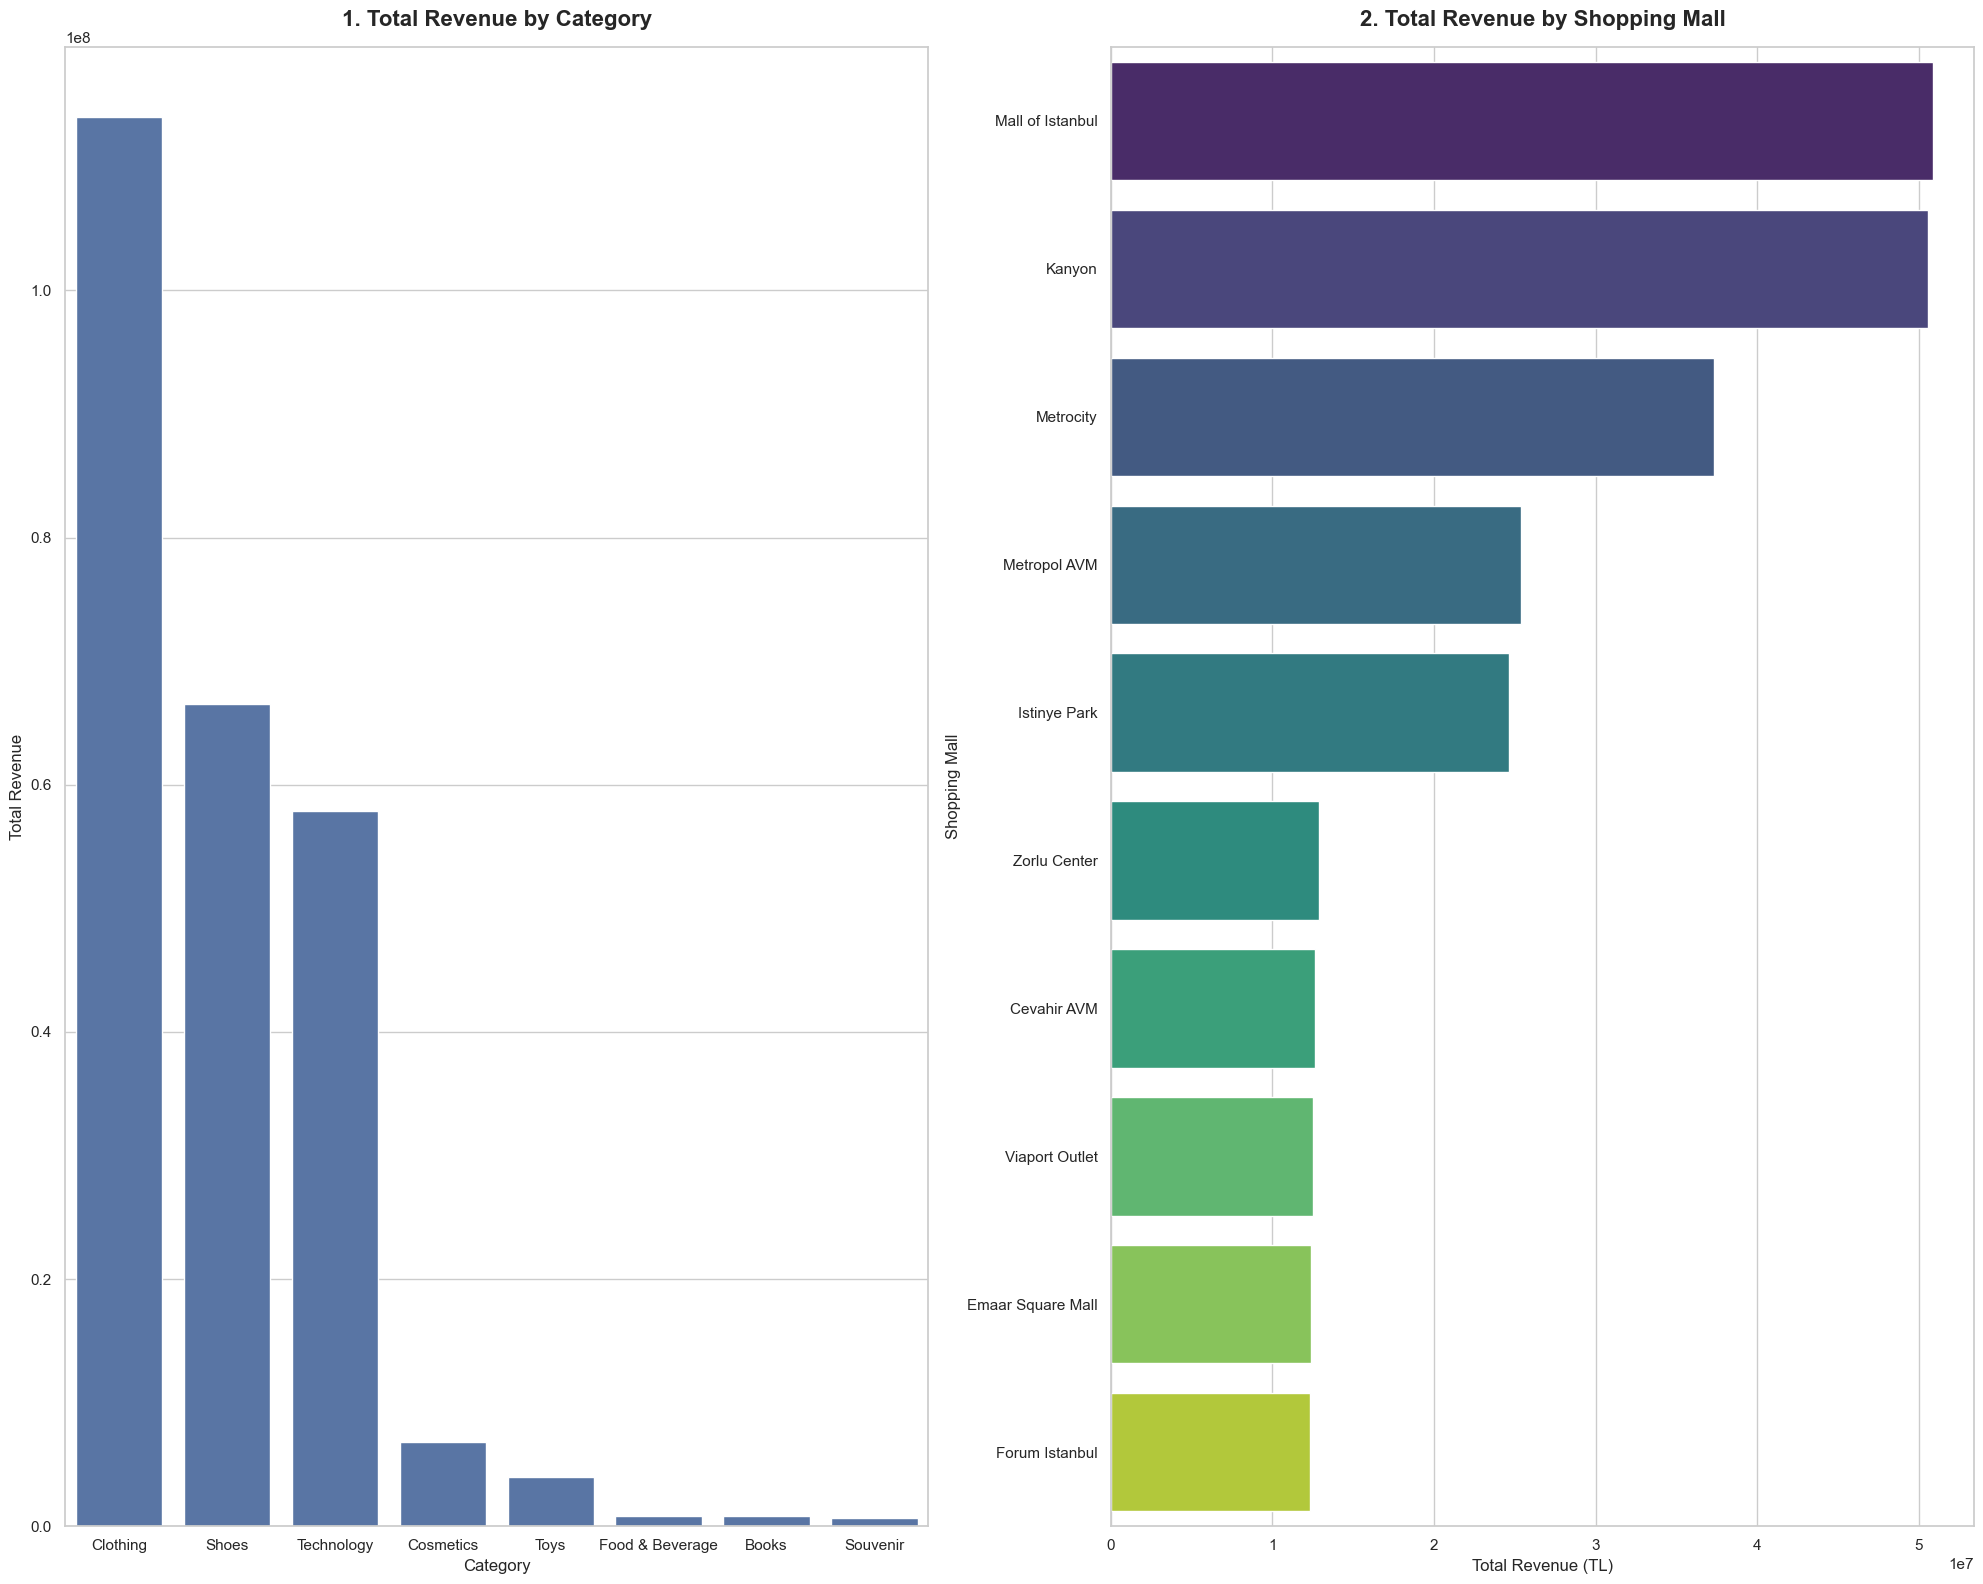

In [30]:
#Revenue Hisgrams

#create a figure and a set of subplots 2X2
f, ax = plt.subplots(1,2, figsize=(20, 16))
sns.set_theme(style="whitegrid")

# category bar chart
sns.barplot(data=category_revenue, x='category', y='Total_Revenue', ax=ax[0])
ax[0].set_title('1. Total Revenue by Category', fontsize=16, fontweight='bold', pad=15)
ax[0].set_xlabel('Category')
ax[0].set_ylabel('Total Revenue')

#mall revenue bar chart
sns.barplot(x='Total_Revenue', y='shopping_mall', data=mall_revenue, palette='viridis', ax=ax[1])
ax[1].set_title('2. Total Revenue by Shopping Mall', fontsize=16, fontweight='bold', pad=15)
ax[1].set_xlabel('Total Revenue (TL)')
ax[1].set_ylabel('Shopping Mall')

plt.tight_layout()
plt.show()


